# Normal vs Uniform action prior — head-to-head

Two sweeps, **identical in every knob except the action prior** (`sweep_normal.yaml` vs
`sweep_uniform.yaml`): same 24 configs × 40 curated inits × same planner seeds. So the runs are
**paired** — we can overlay them on shared charts *and* compare matched (config, init) trees
one-for-one. Built on the `charts` module + a small overlay helper.

## Setup — load both runs, tag by prior

In [31]:
from dreamerv4uwm.planning.experiments.study.analysis import dataset, charts, schema
import numpy as np, pandas as pd, matplotlib.pyplot as plt
%matplotlib inline
pd.set_option("display.width", 180)

BASE = "mcts_sweep"
RUNS = {"normal": f"{BASE}/mcts_sweep_run_normal", "uniform": f"{BASE}/mcts_sweep_run_uniform"}
dfs = {}
for label, d in RUNS.items():
    di = dataset.build(d)          # concat shards + dedup within-run + success flags
    di["prior"] = label
    dfs[label] = di
df = pd.concat(dfs.values(), ignore_index=True)     # both runs stacked; `prior` distinguishes them
print({k: len(v) for k, v in dfs.items()}, "-> combined", len(df), "rows")

KNOBS = [k for k in schema.FACTORS if k in df.columns and df[k].nunique(dropna=True) > 1 and k != "action_prior"]
OUT = "g_random"
COL = {"normal": "#4c78a8", "uniform": "#e45756"}   # one colour per prior, used everywhere
print("knobs compared:", KNOBS)

{'normal': 960, 'uniform': 960} -> combined 1920 rows
knobs compared: ['ctx_noise', 'horizon', 'sim_horizon', 'branching', 'action_temp', 'c_ucb', 'max_depth']


In [32]:
# overlay helper: one response line PER prior on the same axes (charts.response is per-outcome,
# this is per-group). A few lines of matplotlib, in the charts spirit.
def overlay_response(factor, y=OUT, ax=None, data=None):
    d = data if data is not None else df
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 3.4))
    for label, sub in d.groupby("prior", observed=True):
        g = charts.ofat(sub, factor).groupby(factor, observed=True)[y]   # that prior's OFAT slice
        idx = g.mean().index
        numeric = pd.api.types.is_numeric_dtype(idx)
        x = idx.to_numpy(float) if numeric else list(range(len(idx)))
        ax.errorbar(x, g.mean().to_numpy(float), yerr=g.sem().to_numpy(float), marker="o", capsize=3,
                    ls=("-" if numeric else "none"), color=COL.get(label), label=label)
        if not numeric:
            ax.set_xticks(list(x), [str(v) for v in idx])
    ax.axhline(0, color="#888", lw=0.8, ls="--")
    ax.set(xlabel=factor, ylabel=y, title=f"{y} vs {factor}")
    ax.legend(title="action_prior", fontsize=8, frameon=False)
    return ax

## 1. Headline — does the prior shape change *whether planning helps*?
`g_random` = beat one undirected rollout, `g_greedy` = beat best-of-N shooting, `tree_peak` = state reached.

In [33]:
g = df.groupby("prior")
summ = pd.DataFrame({
    "g_random_mean":  g.g_random.mean(),  "g_random_win%":  g.g_random.apply(lambda s: 100*(s > 0).mean()),
    "g_greedy_mean":  g.g_greedy.mean(),  "g_greedy_win%":  g.g_greedy.apply(lambda s: 100*(s > 0).mean()),
    "tree_peak_mean": g.tree_peak.mean(), "reach_T%":       g.tree_peak.apply(lambda s: 100*(s >= 0.7).mean()),
})
display(summ.round(3))

,g_random_mean,g_random_win%,g_greedy_mean,g_greedy_win%,tree_peak_mean,reach_T%
prior,,,,,,
normal,-0.010,42.396,-0.051,8.229,0.670,50.729
uniform,-0.012,40.000,-0.052,10.000,0.668,49.583


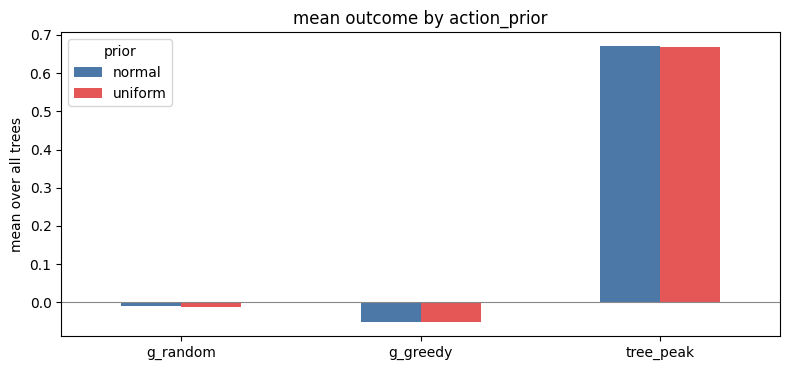

In [34]:
outs = ["g_random", "g_greedy", "tree_peak"]
m = df.groupby("prior")[outs].mean().T           # outcomes on x, one bar-group per prior
ax = m.plot(kind="bar", figsize=(8, 3.8), color=[COL["normal"], COL["uniform"]])
ax.axhline(0, color="#888", lw=0.8); ax.set_ylabel("mean over all trees")
ax.set_title("mean outcome by action_prior"); plt.xticks(rotation=0); plt.tight_layout()

## 2. Knob response curves, overlaid (normal vs uniform on the same axes)

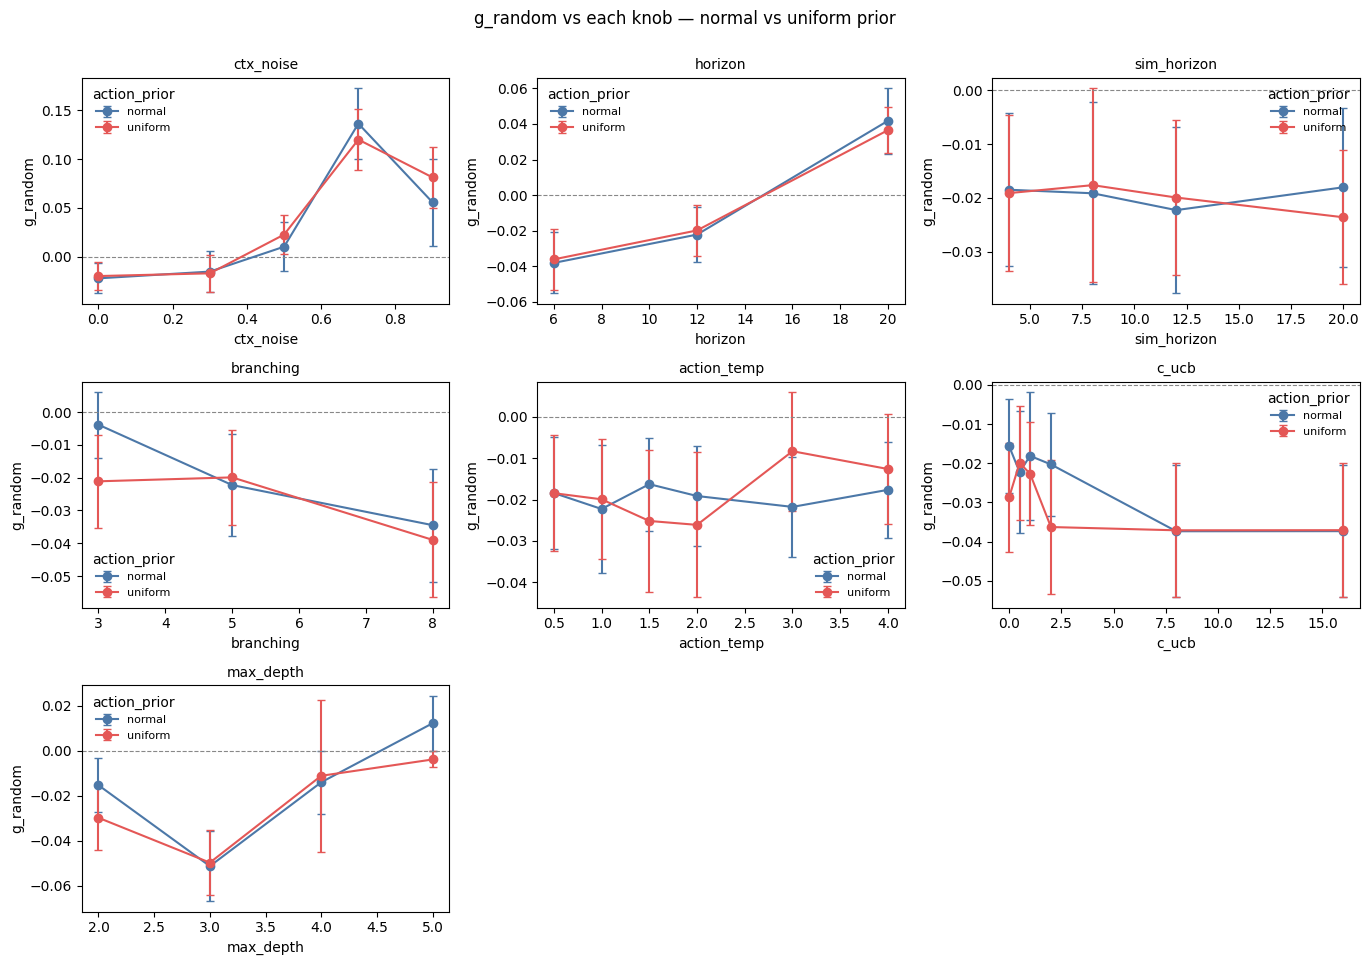

In [35]:
n = len(KNOBS); ncol = 3; nrow = int(np.ceil(n / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(4.6 * ncol, 3.2 * nrow))
for ax, k in zip(axes.ravel(), KNOBS):
    overlay_response(k, OUT, ax=ax); ax.set_title(k, fontsize=10)
for ax in axes.ravel()[n:]:
    ax.axis("off")
fig.suptitle(f"{OUT} vs each knob — normal vs uniform prior", y=1.0); fig.tight_layout()

### 2'. Where the prior lives: `action_temp` (both control action dispersion)
The prior *shape* should matter most where the action sampler is stretched — high `action_temp`.

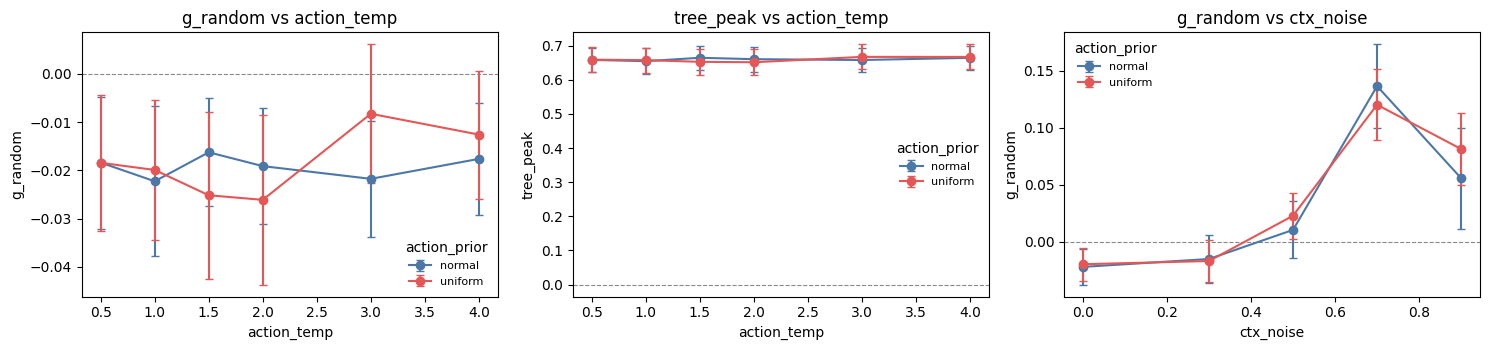

In [36]:
fig, ax = plt.subplots(1, 3, figsize=(15, 3.6))
overlay_response("action_temp", "g_random", ax=ax[0])
overlay_response("action_temp", "tree_peak", ax=ax[1])
overlay_response("ctx_noise",   "g_random", ax=ax[2])
fig.tight_layout()

## 3. Outcome distributions, overlaid

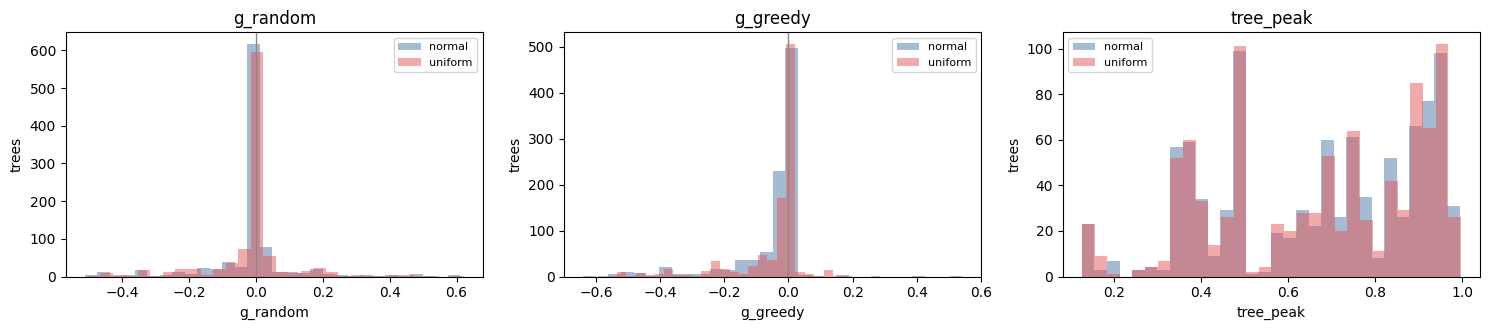

In [37]:
fig, ax = plt.subplots(1, 3, figsize=(15, 3.4))
for a, c in zip(ax, ["g_random", "g_greedy", "tree_peak"]):
    for label, sub in df.groupby("prior", observed=True):
        a.hist(sub[c].dropna(), bins=30, alpha=0.5, label=label, color=COL[label])
    if c != "tree_peak":
        a.axvline(0, color="#888", lw=1)
    a.set(xlabel=c, ylabel="trees", title=c); a.legend(fontsize=8)
fig.tight_layout()

## 4. Paired A/B — same config, same init, same seed
The two runs share every `(config_id, init_id)`, so each is a *controlled* pair: only the prior
differs. Above the diagonal ⇒ uniform beat normal on that exact tree.

960 matched (config, init) pairs

  g_random   : uniform - normal  mean=-0.002   uniform>normal in 46% of pairs
  g_greedy   : uniform - normal  mean=-0.001   uniform>normal in 52% of pairs
  tree_peak  : uniform - normal  mean=-0.002   uniform>normal in 45% of pairs


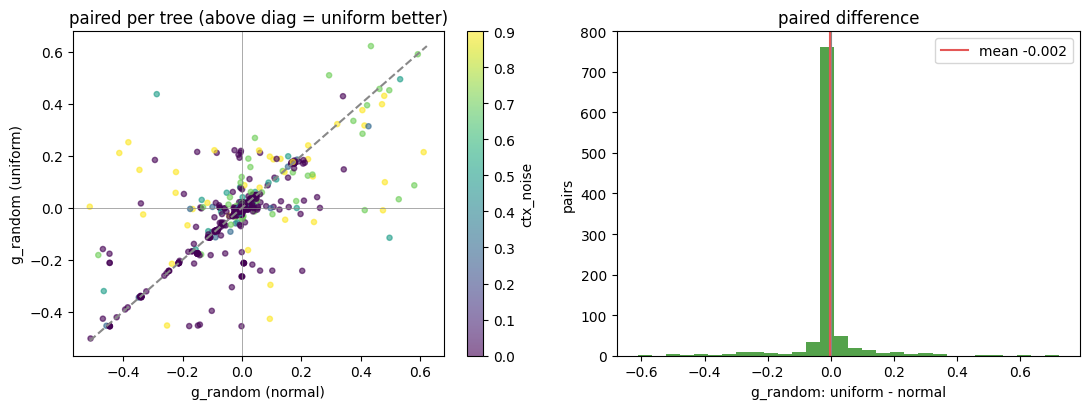

In [38]:
key = ["config_id", "init_id"]
mg = dfs["normal"].merge(dfs["uniform"], on=key, suffixes=("_n", "_u"))
print(f"{len(mg)} matched (config, init) pairs\n")
for y in ["g_random", "g_greedy", "tree_peak"]:
    d = mg[f"{y}_u"] - mg[f"{y}_n"]
    print(f"  {y:11s}: uniform - normal  mean={d.mean():+.3f}   uniform>normal in {(d > 0).mean():.0%} of pairs")

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
sc = ax[0].scatter(mg.g_random_n, mg.g_random_u, c=mg.ctx_noise_n, cmap="viridis", s=14, alpha=0.6)
lim = [mg[["g_random_n", "g_random_u"]].min().min(), mg[["g_random_n", "g_random_u"]].max().max()]
ax[0].plot(lim, lim, "--", color="#888"); ax[0].axhline(0, color="#888", lw=.5); ax[0].axvline(0, color="#888", lw=.5)
ax[0].set(xlabel="g_random (normal)", ylabel="g_random (uniform)", title="paired per tree (above diag = uniform better)")
fig.colorbar(sc, ax=ax[0], label="ctx_noise")
d = mg.g_random_u - mg.g_random_n
ax[1].hist(d, bins=30, color="#54a24b"); ax[1].axvline(0, color="#888")
ax[1].axvline(d.mean(), color="#e45756", label=f"mean {d.mean():+.3f}")
ax[1].set(xlabel="g_random: uniform - normal", ylabel="pairs", title="paired difference"); ax[1].legend()
fig.tight_layout()

## 5. Do the same signals predict success under both priors?

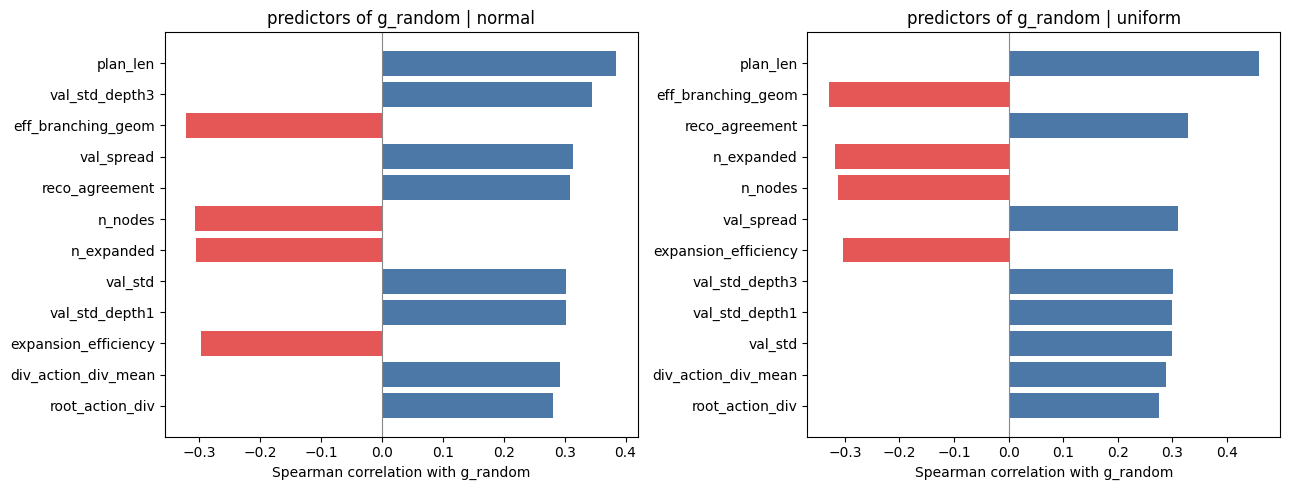

In [39]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
charts.corr_bars(df[df.prior == "normal"],  OUT, top=12, ax=ax[0]); ax[0].set_title(f"predictors of {OUT} | normal")
charts.corr_bars(df[df.prior == "uniform"], OUT, top=12, ax=ax[1]); ax[1].set_title(f"predictors of {OUT} | uniform")
fig.tight_layout()

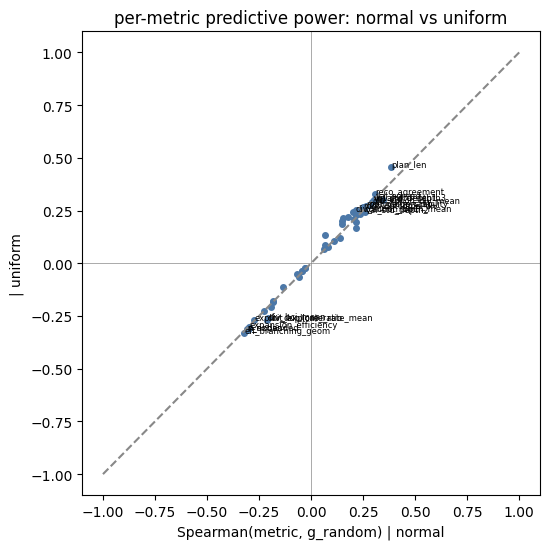

In [40]:
cn = charts.correlations(df[df.prior == "normal"],  OUT).rename("normal")
cu = charts.correlations(df[df.prior == "uniform"], OUT).rename("uniform")
c = pd.concat([cn, cu], axis=1).dropna()
fig, ax = plt.subplots(figsize=(5.6, 5.6))
ax.scatter(c.normal, c.uniform, s=16, color="#4c78a8")
for mname, r in c.iterrows():
    if abs(r.normal) > 0.25 or abs(r.uniform) > 0.25:
        ax.annotate(mname, (r.normal, r.uniform), fontsize=6)
ax.plot([-1, 1], [-1, 1], "--", color="#888"); ax.axhline(0, color="#888", lw=.5); ax.axvline(0, color="#888", lw=.5)
ax.set(xlabel=f"Spearman(metric, {OUT}) | normal", ylabel=f"| uniform",
       title="per-metric predictive power: normal vs uniform"); fig.tight_layout()

### Notes
- Every chart splits by `prior` (== `action_prior`), coloured consistently (blue=normal, red=uniform).
- Section 4 is the cleanest read: it holds config+init+seed fixed, so any difference is the prior alone.
- Swap `OUT` in the setup cell to re-run sections 2/5 for `g_greedy` or `tree_peak`.